In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = df = pd.read_csv(r'E:\Data_analysis_project\Extended_Employee_Performance_and_Productivity_Data.csv')

print(df)

       Employee_ID        Department  Gender  Age   Job_Title  \
0                1                IT    Male   55  Specialist   
1                2           Finance    Male   29   Developer   
2                3           Finance    Male   55  Specialist   
3                4  Customer Support  Female   48     Analyst   
4                5       Engineering  Female   36     Analyst   
...            ...               ...     ...  ...         ...   
99995        99996           Finance    Male   27  Technician   
99996        99997                IT  Female   36  Consultant   
99997        99998        Operations    Male   53     Analyst   
99998        99999                HR  Female   22  Consultant   
99999       100000           Finance  Female   43     Analyst   

                        Hire_Date  Years_At_Company Education_Level  \
0      2022-01-19 08:03:05.556036                 2     High School   
1      2024-04-18 08:03:05.556036                 0     High School   
2     

In [4]:
# Basic info
print("Shape:", df.shape)
print("\nColumn info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

# Performance score distribution
print("\nPerformance Score distribution:")
print(df['Performance_Score'].value_counts().sort_index())

# Summary stats
print("\nSummary statistics:")
print(df.describe())

Shape: (100000, 20)

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Employee_ID                  100000 non-null  int64  
 1   Department                   100000 non-null  object 
 2   Gender                       100000 non-null  object 
 3   Age                          100000 non-null  int64  
 4   Job_Title                    100000 non-null  object 
 5   Hire_Date                    100000 non-null  object 
 6   Years_At_Company             100000 non-null  int64  
 7   Education_Level              100000 non-null  object 
 8   Performance_Score            100000 non-null  int64  
 9   Monthly_Salary               100000 non-null  float64
 10  Work_Hours_Per_Week          100000 non-null  int64  
 11  Projects_Handled             100000 non-null  int64  
 12  Overtime_Hours           

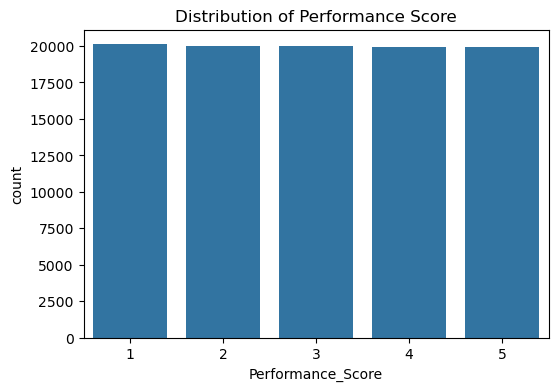

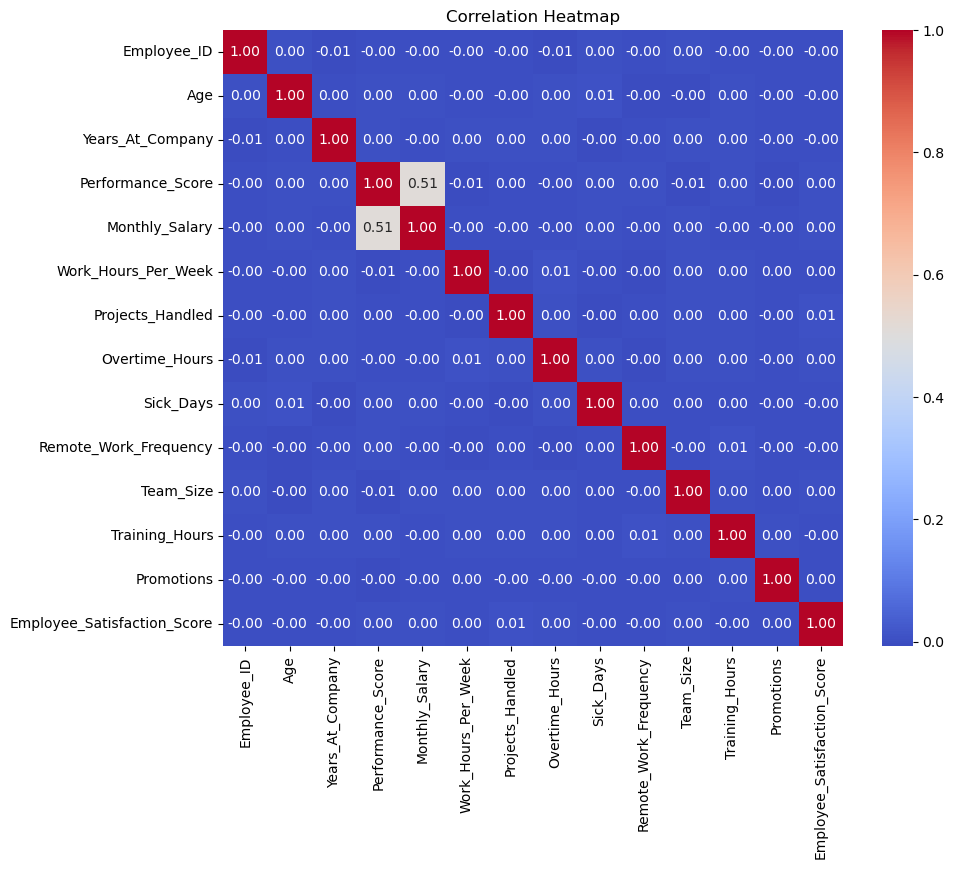

Performance_Score              1.000000
Monthly_Salary                 0.510035
Sick_Days                      0.002994
Training_Hours                 0.002358
Remote_Work_Frequency          0.001733
Employee_Satisfaction_Score    0.001696
Years_At_Company               0.001598
Age                            0.001598
Projects_Handled               0.000640
Overtime_Hours                -0.001312
Employee_ID                   -0.002077
Promotions                    -0.003501
Team_Size                     -0.005174
Work_Hours_Per_Week           -0.005627
Name: Performance_Score, dtype: float64


In [5]:
# Distribution of Performance Score
plt.figure(figsize=(6,4))
sns.countplot(x='Performance_Score', data=df)
plt.title('Distribution of Performance Score')
plt.show()

# Correlation heatmap (numeric columns only)
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Correlation specifically with Performance_Score, sorted
corr = numeric_df.corr()['Performance_Score'].sort_values(ascending=False)
print(corr)

In [6]:
# 1. Overtime ratio - how much of their work week is overtime
df['Overtime_Ratio'] = df['Overtime_Hours'] / df['Work_Hours_Per_Week']

# 2. Promotion rate - promotions per year of tenure (avoid div by zero with +1)
df['Promotion_Rate'] = df['Promotions'] / (df['Years_At_Company'] + 1)

# 3. Projects per year of tenure - workload intensity relative to experience
df['Projects_Per_Year'] = df['Projects_Handled'] / (df['Years_At_Company'] + 1)

# 4. Composite engagement score - combines training, projects, low absenteeism
# Normalize each component to 0-1 first, then average
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
engagement_cols = ['Training_Hours', 'Projects_Handled', 'Employee_Satisfaction_Score']
scaled = scaler.fit_transform(df[engagement_cols])
df['Engagement_Score'] = scaled.mean(axis=1)

# 5. Salary band - bucket salary into quartile-based categories
df['Salary_Band'] = pd.qcut(df['Monthly_Salary'], q=4, labels=['Low','Medium','High','Very High'])

# 6. Tenure group - junior/mid/senior
df['Tenure_Group'] = pd.cut(df['Years_At_Company'], bins=[-1,2,5,11], labels=['Junior','Mid','Senior'])

# 7. Age group
df['Age_Group'] = pd.cut(df['Age'], bins=[20,30,40,50,61], labels=['20s','30s','40s','50s+'])

print(df[['Overtime_Ratio','Promotion_Rate','Projects_Per_Year','Engagement_Score','Salary_Band','Tenure_Group','Age_Group']].head())

   Overtime_Ratio  Promotion_Rate  Projects_Per_Year  Engagement_Score  \
0        0.666667           0.000          10.666667          0.575743   
1        0.382353           2.000          34.000000          0.496680   
2        0.162162           0.000           3.000000          0.367874   
3        0.538462           0.125           1.250000          0.139694   
4        0.763158           0.250           2.750000          0.125966   

  Salary_Band Tenure_Group Age_Group  
0        High       Junior      50s+  
1        High       Junior       20s  
2      Medium       Senior      50s+  
3         Low       Senior       40s  
4         Low          Mid       30s  


Overtime_Ratio       0.000819
Promotion_Rate      -0.001631
Projects_Per_Year   -0.002514
Engagement_Score     0.002697
Performance_Score    1.000000
Name: Performance_Score, dtype: float64
Salary_Band
Low          2.434373
Medium       2.769302
High         2.781002
Very High    4.123141
Name: Performance_Score, dtype: float64


C:\Users\AM COMPUTER\AppData\Local\Temp\ipykernel_15636\1956950001.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Salary_Band')['Performance_Score'].mean())


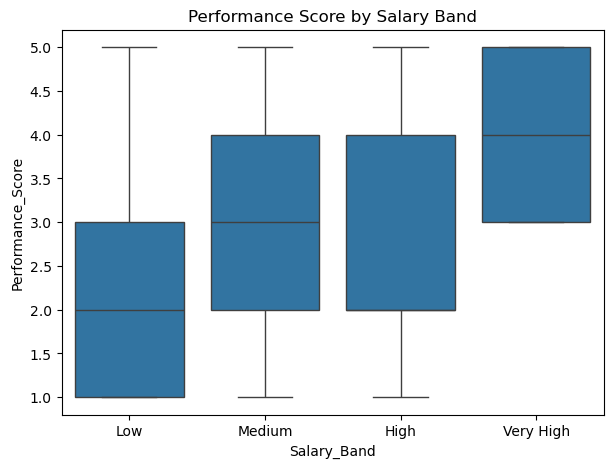

In [7]:
# Check correlation of new numeric features with Performance_Score
new_numeric = ['Overtime_Ratio','Promotion_Rate','Projects_Per_Year','Engagement_Score']
print(df[new_numeric + ['Performance_Score']].corr()['Performance_Score'])

# Check Performance_Score by Salary_Band - this is the one I'd bet shows a real pattern
print(df.groupby('Salary_Band')['Performance_Score'].mean())

# Boxplot to visualize Salary_Band vs Performance_Score
plt.figure(figsize=(7,5))
sns.boxplot(x='Salary_Band', y='Performance_Score', data=df)
plt.title('Performance Score by Salary Band')
plt.show()

In [8]:
# Define binary target: High Performer = Performance_Score 4 or 5
df['High_Performer'] = (df['Performance_Score'] >= 4).astype(int)
print(df['High_Performer'].value_counts(normalize=True))

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Model A: "Engagement" features only - mirrors the task's framing
engagement_features = [
    'Training_Hours', 'Projects_Handled', 'Overtime_Hours', 'Sick_Days',
    'Remote_Work_Frequency', 'Employee_Satisfaction_Score', 'Work_Hours_Per_Week',
    'Overtime_Ratio', 'Promotion_Rate', 'Projects_Per_Year', 'Engagement_Score'
]

X = df[engagement_features]
y = df['High_Performer']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model_a = LogisticRegression(max_iter=1000)
model_a.fit(X_train, y_train)

y_pred = model_a.predict(X_test)
print("Model A (Engagement features only) Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

High_Performer
0    0.60132
1    0.39868
Name: proportion, dtype: float64
Model A (Engagement features only) Accuracy: 0.6013
              precision    recall  f1-score   support

           0       0.60      1.00      0.75     12026
           1       0.00      0.00      0.00      7974

    accuracy                           0.60     20000
   macro avg       0.30      0.50      0.38     20000
weighted avg       0.36      0.60      0.45     20000

[[12026     0]
 [ 7974     0]]


C:\Users\AM COMPUTER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\AM COMPUTER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\AM COMPUTER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
# Model B: Salary + job-related features
# One-hot encode categorical columns (turns categories into 0/1 columns the model can use)
categorical_features = ['Department', 'Job_Title', 'Education_Level']
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

job_features = ['Monthly_Salary', 'Years_At_Company', 'Age', 'Team_Size'] + \
    [col for col in df_encoded.columns if col.startswith(('Department_', 'Job_Title_', 'Education_Level_'))]

X_b = df_encoded[job_features]
y_b = df_encoded['High_Performer']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_b, y_b, test_size=0.2, random_state=42, stratify=y_b)

model_b = LogisticRegression(max_iter=1000)
model_b.fit(X_train_b, y_train_b)

y_pred_b = model_b.predict(X_test_b)
print("Model B (Salary/Job features) Accuracy:", accuracy_score(y_test_b, y_pred_b))
print(classification_report(y_test_b, y_pred_b, zero_division=0))
print(confusion_matrix(y_test_b, y_pred_b))


Model B (Salary/Job features) Accuracy: 0.99855
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12026
           1       1.00      1.00      1.00      7974

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000

[[11997    29]
 [    0  7974]]


C:\Users\AM COMPUTER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [11]:
# Isolate Monthly_Salary alone - if accuracy is still near-perfect, that confirms leakage
X_salary_only = df_encoded[['Monthly_Salary']]
y_salary = df_encoded['High_Performer']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_salary_only, y_salary, test_size=0.2, random_state=42, stratify=y_salary)

model_salary = LogisticRegression(max_iter=1000)
model_salary.fit(X_train_s, y_train_s)

y_pred_s = model_salary.predict(X_test_s)
print("Salary-only Accuracy:", accuracy_score(y_test_s, y_pred_s))
print(confusion_matrix(y_test_s, y_pred_s))

# Also check: what does Monthly_Salary look like at the boundary between performance levels?
print(df.groupby('Performance_Score')['Monthly_Salary'].agg(['min','max','mean']))

Salary-only Accuracy: 0.65745
[[9170 2856]
 [3995 3979]]
                      min     max         mean
Performance_Score                             
1                  3850.0  6600.0  5422.229125
2                  4200.0  7200.0  5900.284815
3                  4550.0  7800.0  6409.515476
4                  4900.0  8400.0  6897.632899
5                  5250.0  9000.0  7397.669109


In [12]:
# Check salary stats grouped by Job_Title AND Performance_Score
print(df.groupby(['Job_Title','Performance_Score'])['Monthly_Salary'].agg(['min','max','mean','std']).head(20))

# Check the salary-performance correlation *within* each job title
print("\nCorrelation of Salary with Performance, by Job_Title:")
for jt in df['Job_Title'].unique():
    subset = df[df['Job_Title'] == jt]
    corr = subset['Monthly_Salary'].corr(subset['Performance_Score'])
    print(f"{jt}: {corr:.3f}")

                                 min     max    mean  std
Job_Title  Performance_Score                             
Analyst    1                  4400.0  4400.0  4400.0  0.0
           2                  4800.0  4800.0  4800.0  0.0
           3                  5200.0  5200.0  5200.0  0.0
           4                  5600.0  5600.0  5600.0  0.0
           5                  6000.0  6000.0  6000.0  0.0
Consultant 1                  6050.0  6050.0  6050.0  0.0
           2                  6600.0  6600.0  6600.0  0.0
           3                  7150.0  7150.0  7150.0  0.0
           4                  7700.0  7700.0  7700.0  0.0
           5                  8250.0  8250.0  8250.0  0.0
Developer  1                  5500.0  5500.0  5500.0  0.0
           2                  6000.0  6000.0  6000.0  0.0
           3                  6500.0  6500.0  6500.0  0.0
           4                  7000.0  7000.0  7000.0  0.0
           5                  7500.0  7500.0  7500.0  0.0
Engineer   1  

In [13]:
# Model C: Same features as Model B, but WITHOUT Monthly_Salary
job_features_no_salary = ['Years_At_Company', 'Age', 'Team_Size'] + \
    [col for col in df_encoded.columns if col.startswith(('Department_', 'Job_Title_', 'Education_Level_'))]

X_c = df_encoded[job_features_no_salary]
y_c = df_encoded['High_Performer']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, random_state=42, stratify=y_c)

model_c = LogisticRegression(max_iter=1000)
model_c.fit(X_train_c, y_train_c)

y_pred_c = model_c.predict(X_test_c)
print("Model C (Job/demographic features, no salary) Accuracy:", accuracy_score(y_test_c, y_pred_c))
print(classification_report(y_test_c, y_pred_c, zero_division=0))
print(confusion_matrix(y_test_c, y_pred_c))

Model C (Job/demographic features, no salary) Accuracy: 0.6013
              precision    recall  f1-score   support

           0       0.60      1.00      0.75     12026
           1       0.00      0.00      0.00      7974

    accuracy                           0.60     20000
   macro avg       0.30      0.50      0.38     20000
weighted avg       0.36      0.60      0.45     20000

[[12026     0]
 [ 7974     0]]
